In [1]:
'''
RAG to be deployed. Followed concepts of rag part 2 tutorial of langchain, but using a persistent db for storing embeddings (quadrant)
'''

'\nRAG to be deployed. Followed concepts of rag part 2 tutorial of langchain, but using a persistent db for storing embeddings (quadrant)\n'

In [1]:
possible_games = ['axis-allies-rules-1942-2nd-edition',
 'Axis_&_Allies_1942_2nd_Reference_v1',
 'Grand_Austria_Hotel_game_aid_-_2_pages_v1',
 'Grand_Austria_Hotel_Plain_and_Simple_Guide',
 'Grand_Hotel_Austria_rules_EN_web',
 'In_The_Footsteps_Of_Marco_Polo_-_English_Overview_Cards',
 'LlamaLand_Player_Aid_(English)_version_2',
 'LlamaLand_Rules_EN',
 'Memoir_44_-_a_beginners_reference',
 'memoir_44_rules_part1_en',
 'Memoir_44_Unofficial_FAQ_v12',
 'munchkindisneyrules',
 'MunchkinDisney_Instr',
 'MYSTERIUM_PARK_RULES_EN_BD',
 'Mysterium_Park_Rules_Summary_unnofficial',
 'Paleo_FAQ_11-12-20_ENG',
 'Paleo_Rulebook_EN_compressed',
 'pandemic season 1 rules',
 'partners',
 'Partners_rules',
 'Power Grid Expansion Benelux Central Europe',
 'Power Grid Expansion India Australia',
 'Power Grid Expansion UK Ireland Northern Europe',
 'Power-Grid-Recharged-Rules',
 'skull_king_rulebook_optimized',
 'splendor',
 'Splendor_Brief_by_Liumas_2014-05b',
 'Take-5-or-6-Nimmt-Rules',
 'Take_5_6nimmt30_rules_english',
 'The_Crew_Demo_Sheet',
 'The_Crew_Manual',
 'Tureluurs official rules EN',
 'Tureluurs official rules',
 'Tureluurs unofficial rules',
 'Voyages Of Marco Polo - English Rules V3',
 'Voyages_Of_Marco_Polo_-_FAQ_and_Errata_V2']

print('We started running rag script')



# Useful to set working directory
from pathlib import Path

# Useful to load api keys for Cohere embeddings and generative model
import os
from dotenv import load_dotenv
load_dotenv()  # Loads from .env
COHERE_API_KEY=os.getenv("COHERE_TOKEN")
os.environ["COHERE_API_KEY"]=COHERE_API_KEY 
from langchain_cohere import CohereEmbeddings
from langchain.chat_models import init_chat_model

# For connecting to the embeddings vector store
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient

# For filtering a vector store
from qdrant_client import models

# For declaring functions as tools to be used by the generative model
from langchain_core.tools import tool

#For declaring custom graph states
from typing_extensions import  TypedDict, List, Annotated
from typing import Sequence
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

# For declaring nodes
from langchain_core.messages import SystemMessage,HumanMessage
from langgraph.graph import MessagesState, START
from langgraph.prebuilt import ToolNode

#For creating the graph
from langgraph.graph import MessagesState, StateGraph
from langgraph.graph import END
from langgraph.prebuilt import  tools_condition

#For adding memory to the graph
from langgraph.checkpoint.memory import MemorySaver

#For logging
import logging

logger = logging.getLogger(__name__)

    

logger.debug('We started running rag script')


######################


# Set working directory
try:
    # Works in regular Python scripts
    base_dir = Path(__file__).resolve().parent.parent.parent
except NameError:
    # Fallback for Jupyter notebooks and interactive shells
    base_dir = Path().resolve().parent.parent

#temp: delete later
base_dir = Path().resolve().parent

########################


# Declare both embeddings and generative models
#embeddings = CohereEmbeddings(model="embed-v4.0") # Langchain wrapper does not allow reducing size to 256
embeddings = CohereEmbeddings(model="embed-multilingual-light-v3.0")  # This dimension is 384. Default of v4.0: 1536

model = init_chat_model("command-a-03-2025", model_provider="cohere") # Cohere api key needs to be as env variable with the name COHERE_API_KEY



########################



# Connect to Qdrant vector store
path_qdrant_vector_store = base_dir / "data" /  "qdrant"
client = QdrantClient(path=path_qdrant_vector_store)
vector_store = QdrantVectorStore(
    client=client,
    collection_name="document_embeddings",
    embedding=embeddings,
)


We started running rag script


In [ ]:
######################


# Approach via Chains
#Our graph will consist of four nodes:

    #1- A node that extracts the possible document names that could help with the answer
    #2- A node for the retriever tool that executes the retrieval step
    #3- A node that generates the final response using the retrieved context.

class StateWithDocsList(TypedDict): 
    messages: Annotated[Sequence[BaseMessage], add_messages] #add_messages appends new messages in the state automatically
    list_useful_docs: List[str]
    concatenated_retrieved_context: str
    should_use_retriever: bool



In [20]:
# Remember: nodes receive a state which is an object with messages and other custom data. messages is a list
#of all messages obtained during the graph, both from the system, the human, and ai
#The content of the last message can be accessed via: state['messages'][-1].content

# Remember: in a graph, all info needed as inputs and outputs should be stored in the state

In [21]:
# Node 1: Extract possible document names.
def get_useful_document_names(state: StateWithDocsList):
    """Finds subset of useful boardgame document names to be used in retrieval"""

    prompt = (
        "You are an assistant that tries to find which boardgame booklets are related to a particular sentence. "
        "First detect the name of the boardgame the user is asking about."
        "Then select from the list of documents the ones that could be related to that boardgame."
        "Then ONLY return the selected documents as a comma-separated list. Nothing else."
        "If you are not sure about including a document, select it just in case"
        "Do not select more than 5 names."
        "If none are relevant, return 'None'. "
        "The list of boardgame booklets is the following: "
        f"{possible_games}"

        "The sentence of the user is:"
        f"{state['messages'][-1].content}"
    )

    response = model.invoke(prompt)
    str_list_useful_docs = response.content #Responses are of type AIMessage

    # Convert string of lists of documents, into a list of strings of documents: 'doc1, doc2' -> ['doc1','doc2']
    list_useful_docs=str_list_useful_docs.split(',')
    list_useful_docs=[astring.strip() for astring in list_useful_docs]
    
    # We make sure that if a new question is asking something of the boardgame of the previous question, but is not
    # mentioning the boardgame name explicitly, we keep the same useful documents (otherwise it would be a 'None').
    if ('list_useful_docs' in state.keys() and 
        state['list_useful_docs']!= ['None'] and 
        list_useful_docs==['None']
        ): 
        state['list_useful_docs']= state['list_useful_docs'] 
    else: 
        state['list_useful_docs']= list_useful_docs

    return state




In [22]:
an_input_state={'messages':[HumanMessage(content='How many players can play Tureluurs?')]}


In [23]:
get_useful_document_names(an_input_state)

c:\Users\Carlos Ivan\Documents\Projects\boardgames-assistant\.venv\lib\site-packages\langsmith\client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


{'messages': [HumanMessage(content='How many players can play Tureluurs?', additional_kwargs={}, response_metadata={})],
 'list_useful_docs': ['Tureluurs official rules EN',
  'Tureluurs official rules',
  'Tureluurs unofficial rules']}

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=6d44670b-b95a-4f8f-bbe5-562de4ecd6db,id=6d44670b-b95a-4f8f-bbe5-562de4ecd6db
Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=6d44670b-b95a-4f8f-bbe5-562de4ecd6db,id=6d44670b-b95a-4f8f-bbe5-562de4ecd6db
Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Una

In [24]:
an_input_state

{'messages': [HumanMessage(content='How many players can play Tureluurs?', additional_kwargs={}, response_metadata={})],
 'list_useful_docs': ['Tureluurs official rules EN',
  'Tureluurs official rules',
  'Tureluurs unofficial rules']}

In [45]:
aux=[amessage for amessage in an_input_state['messages'] if amessage.type=='human'][-1]
aux

HumanMessage(content='How many players can play Tureluurs?', additional_kwargs={}, response_metadata={})

In [25]:
def retriever(state: StateWithDocsList): # This receives a string as input and not a state bc it is not a node. This tool will be added into a node, that needs as input a State
    """Retrieve information related to a query."""
    nr_vector_store_documents=client.count(collection_name=vector_store.collection_name).count  # Works for Qdrant vector_store
    #print(nr_vector_store_documents)
    logger.debug(f'Size of vector store until now: {nr_vector_store_documents}')

    #Get last question of the human
    all_human_messages = [amessage for amessage in state['messages'] if amessage.type=='human']
    last_human_message = all_human_messages[-1]

    filter_docs=models.Filter( #Filter to be used in the similarity search
        should=[
            models.FieldCondition(
                key="metadata.game",
                match=models.MatchAny(any=state['list_useful_docs'])    
            ),
        ]
    )
    logger.debug(f"Starts vector similarity search")
    # This is were the app crashes due to lack of memory
    retrieved_docs = vector_store.similarity_search(
        last_human_message.content, 
        k= 8, #4,
        filter=filter_docs #This is what filters to only documents with specific metadata
        ) # Tried this to make it lighter but never worked(query, k=1, search_params={"ef": 4})
    logger.debug("Vector similarity done")
    concat_context = "\n\n".join(  #The concatenation of docs as strings was done in the generate function before, and it did not include metadata
        (f"Content: {doc.page_content}") 
        for doc in retrieved_docs 
    )
    state['concatenated_retrieved_context'] = concat_context
    logger.debug("End of retrieval tool")

    return state


In [26]:
an_input_state

{'messages': [HumanMessage(content='How many players can play Tureluurs?', additional_kwargs={}, response_metadata={})],
 'list_useful_docs': ['Tureluurs official rules EN',
  'Tureluurs official rules',
  'Tureluurs unofficial rules']}

In [27]:
retriever(an_input_state)

{'messages': [HumanMessage(content='How many players can play Tureluurs?', additional_kwargs={}, response_metadata={})],
 'list_useful_docs': ['Tureluurs official rules EN',
  'Tureluurs official rules',
  'Tureluurs unofficial rules'],
 'concatenated_retrieved_context': "Content: Game: Tureluurs unofficial rules, page 1. Content: the Bird Guide. The birding season is over and our feathered friends all migrated. \n \nSolo variant \nTureluurs can also be played solo. It then works virtually the same as a multiplayer game, \nwith the major difference being that you play each turn with a hand of five cards, three of \nwhich you choose to play. In doing so, you are required to play Events first. The two \nremaining cards go to the discard pile at the end of your turn. In addition, there are a few \nEvents that have been slightly modified. The scoring is the same as in the base game. \nWhat do I think of Tureluurs? \n \nTheme \nThe theme of the game is actually reflected in the game play an

In [28]:
an_input_state

{'messages': [HumanMessage(content='How many players can play Tureluurs?', additional_kwargs={}, response_metadata={})],
 'list_useful_docs': ['Tureluurs official rules EN',
  'Tureluurs official rules',
  'Tureluurs unofficial rules'],
 'concatenated_retrieved_context': "Content: Game: Tureluurs unofficial rules, page 1. Content: the Bird Guide. The birding season is over and our feathered friends all migrated. \n \nSolo variant \nTureluurs can also be played solo. It then works virtually the same as a multiplayer game, \nwith the major difference being that you play each turn with a hand of five cards, three of \nwhich you choose to play. In doing so, you are required to play Events first. The two \nremaining cards go to the discard pile at the end of your turn. In addition, there are a few \nEvents that have been slightly modified. The scoring is the same as in the base game. \nWhat do I think of Tureluurs? \n \nTheme \nThe theme of the game is actually reflected in the game play an

In [29]:
# Node 3: Generate a response using the retrieved content. This will only be run if we retrieved data from the vector_store
def generate(state: StateWithDocsList): #This state contains the original query as a human message + the context from the retriever as an ai message
    """Generate answer."""
    # Get generated ToolMessages
    logger.debug("Start of node generate")


    #maybe try using tools and see if it works or not?
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer the question. "
        "If you don't know the answer, just say that you don't know, don't try to make up an answer."
        "Use between three to 5 sentences maximum and keep the answer concise."
        "\n\n"
        f"{state['concatenated_retrieved_context']}"
    )
    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls) #excludes ai messages from the retriever (I think not doing this will output 1 extra message per doc extracted)
    ]
    prompt = [SystemMessage(system_message_content)] + conversation_messages #This is done to let know the chatbot of the interaction between human and ai, including the last question to answer
    logger.debug(f'Prompt for generate function: {prompt}' )

    # Run
    response = model.invoke(prompt)
    logger.debug("End of generate node")

    state['messages'] = state['messages'] + [response] 

    return state

In [30]:
an_input_state

{'messages': [HumanMessage(content='How many players can play Tureluurs?', additional_kwargs={}, response_metadata={})],
 'list_useful_docs': ['Tureluurs official rules EN',
  'Tureluurs official rules',
  'Tureluurs unofficial rules'],
 'concatenated_retrieved_context': "Content: Game: Tureluurs unofficial rules, page 1. Content: the Bird Guide. The birding season is over and our feathered friends all migrated. \n \nSolo variant \nTureluurs can also be played solo. It then works virtually the same as a multiplayer game, \nwith the major difference being that you play each turn with a hand of five cards, three of \nwhich you choose to play. In doing so, you are required to play Events first. The two \nremaining cards go to the discard pile at the end of your turn. In addition, there are a few \nEvents that have been slightly modified. The scoring is the same as in the base game. \nWhat do I think of Tureluurs? \n \nTheme \nThe theme of the game is actually reflected in the game play an

In [31]:
generate(an_input_state)

{'messages': [HumanMessage(content='How many players can play Tureluurs?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', additional_kwargs={'id': 'b1c3b6a0-d655-4169-8fb5-3ddad52e8503', 'finish_reason': 'COMPLETE', 'content': 'Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', 'token_count': {'input_tokens': 3020.0, 'output_tokens': 34.0}}, response_metadata={'id': 'b1c3b6a0-d655-4169-8fb5-3ddad52e8503', 'finish_reason': 'COMPLETE', 'content': 'Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', 'token_count': {'input_tokens': 3020.0, 'output_tokens': 34.0}}, id='run--a1b05d13-0c11-489f-a083-d5e25a6b1e61-0', usage_metadata={'

In [32]:
an_input_state

{'messages': [HumanMessage(content='How many players can play Tureluurs?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', additional_kwargs={'id': 'b1c3b6a0-d655-4169-8fb5-3ddad52e8503', 'finish_reason': 'COMPLETE', 'content': 'Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', 'token_count': {'input_tokens': 3020.0, 'output_tokens': 34.0}}, response_metadata={'id': 'b1c3b6a0-d655-4169-8fb5-3ddad52e8503', 'finish_reason': 'COMPLETE', 'content': 'Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', 'token_count': {'input_tokens': 3020.0, 'output_tokens': 34.0}}, id='run--a1b05d13-0c11-489f-a083-d5e25a6b1e61-0', usage_metadata={'

In [33]:

### Declaration of the graph ###


#graph_builder = StateGraph(MessagesState) #Input of the graph is of the type MessagesState
graph_builder=StateGraph(state_schema= StateWithDocsList)

#declaration of nodes
graph_builder.add_node(get_useful_document_names)
graph_builder.add_node(retriever)
graph_builder.add_node(generate)

#set starting nodes
graph_builder.add_edge(START, "get_useful_document_names")
graph_builder.add_edge("get_useful_document_names", "retriever")
graph_builder.add_edge("retriever", "generate")
graph_builder.add_edge("generate", END)
#set conditional node
#add the one suggested by chatgpt

#declaration of memory
memory = MemorySaver()
#graph compilation
graph = graph_builder.compile(checkpointer=memory)


print('We finished running rag script')




We finished running rag script


# End of code to be tested. Now testing starts

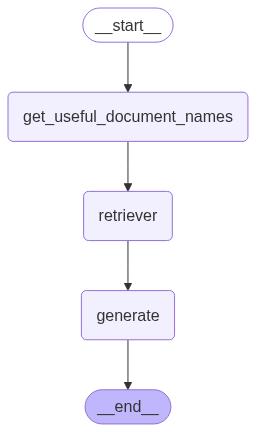

In [34]:
# To visualize flow: 
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [35]:


# Specify an ID for the thread
config = {"configurable": {"thread_id": "abc123"}}

In [36]:
an_input_state_1={'messages':[HumanMessage(content='How many players can play Tureluurs?')]}


In [37]:

graph.invoke(an_input_state_1, config=config)

{'messages': [HumanMessage(content='How many players can play Tureluurs?', additional_kwargs={}, response_metadata={}, id='26fcfe2c-9a60-4ed8-835a-989fa60912f0'),
  AIMessage(content='Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', additional_kwargs={'id': '0c43692d-fa2f-4c43-8ea1-3a49797b9989', 'finish_reason': 'COMPLETE', 'content': 'Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', 'token_count': {'input_tokens': 3020.0, 'output_tokens': 34.0}}, response_metadata={'id': '0c43692d-fa2f-4c43-8ea1-3a49797b9989', 'finish_reason': 'COMPLETE', 'content': 'Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', 'token_count': {'input_tokens': 3020.0, 'output_tokens': 34.0}}, id='run--f9294a1e-9342-4

In [ ]:
input_message='What was my last question?' #should not generate context


graph.invoke({"messages": [{"role": "user", "content": input_message}]}, config=config)

{'messages': [HumanMessage(content='How many players can play Tureluurs?', additional_kwargs={}, response_metadata={}, id='26fcfe2c-9a60-4ed8-835a-989fa60912f0'),
  AIMessage(content='Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', additional_kwargs={'id': '0c43692d-fa2f-4c43-8ea1-3a49797b9989', 'finish_reason': 'COMPLETE', 'content': 'Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', 'token_count': {'input_tokens': 3020.0, 'output_tokens': 34.0}}, response_metadata={'id': '0c43692d-fa2f-4c43-8ea1-3a49797b9989', 'finish_reason': 'COMPLETE', 'content': 'Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', 'token_count': {'input_tokens': 3020.0, 'output_tokens': 34.0}}, id='run--f9294a1e-9342-4

In [ ]:
input_message='And how do you win that game?' #should generate context


graph.invoke({"messages": [{"role": "user", "content": input_message}]}, config=config)

{'messages': [HumanMessage(content='How many players can play Tureluurs?', additional_kwargs={}, response_metadata={}, id='26fcfe2c-9a60-4ed8-835a-989fa60912f0'),
  AIMessage(content='Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', additional_kwargs={'id': '0c43692d-fa2f-4c43-8ea1-3a49797b9989', 'finish_reason': 'COMPLETE', 'content': 'Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', 'token_count': {'input_tokens': 3020.0, 'output_tokens': 34.0}}, response_metadata={'id': '0c43692d-fa2f-4c43-8ea1-3a49797b9989', 'finish_reason': 'COMPLETE', 'content': 'Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', 'token_count': {'input_tokens': 3020.0, 'output_tokens': 34.0}}, id='run--f9294a1e-9342-4

In [ ]:
input_message='How do you win at Power grid Australia?' #Should change list of useful docs


graph.invoke({"messages": [{"role": "user", "content": input_message}]}, config=config)

{'messages': [HumanMessage(content='How many players can play Tureluurs?', additional_kwargs={}, response_metadata={}, id='26fcfe2c-9a60-4ed8-835a-989fa60912f0'),
  AIMessage(content='Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', additional_kwargs={'id': '0c43692d-fa2f-4c43-8ea1-3a49797b9989', 'finish_reason': 'COMPLETE', 'content': 'Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', 'token_count': {'input_tokens': 3020.0, 'output_tokens': 34.0}}, response_metadata={'id': '0c43692d-fa2f-4c43-8ea1-3a49797b9989', 'finish_reason': 'COMPLETE', 'content': 'Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', 'token_count': {'input_tokens': 3020.0, 'output_tokens': 34.0}}, id='run--f9294a1e-9342-4

In [ ]:
input_message='Is it sunny today?' #Should keep list of docs just in case but should have no context and should not go
#through the retriever


graph.invoke({"messages": [{"role": "user", "content": input_message}]}, config=config)

{'messages': [HumanMessage(content='How many players can play Tureluurs?', additional_kwargs={}, response_metadata={}, id='26fcfe2c-9a60-4ed8-835a-989fa60912f0'),
  AIMessage(content='Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', additional_kwargs={'id': '0c43692d-fa2f-4c43-8ea1-3a49797b9989', 'finish_reason': 'COMPLETE', 'content': 'Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', 'token_count': {'input_tokens': 3020.0, 'output_tokens': 34.0}}, response_metadata={'id': '0c43692d-fa2f-4c43-8ea1-3a49797b9989', 'finish_reason': 'COMPLETE', 'content': 'Tureluurs is a cooperative card game designed for **two to four players**. Additionally, it includes a **solo variant** for single-player gameplay.', 'token_count': {'input_tokens': 3020.0, 'output_tokens': 34.0}}, id='run--f9294a1e-9342-4

In [16]:
input_message='In Tureluurs, what does the "Lost binoculars" card do?'

answer=graph.invoke({"messages": [{"role": "user", "content": input_message}]}, config=config)

In [17]:
answer

{'messages': [HumanMessage(content='How do you win at power grid?', additional_kwargs={}, response_metadata={}, id='81447ff1-f54e-4057-86b7-18fd90c830b5'),
  AIMessage(content="I will search for 'how to win at power grid?'", additional_kwargs={'id': 'a614a635-4c43-437e-bca9-bccfe1554511', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid?'", 'tool_calls': [{'id': 'retrieve_h3g5jw90betz', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid?"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 53.0}}, response_metadata={'id': 'a614a635-4c43-437e-bca9-bccfe1554511', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid?'", 'tool_calls': [{'id': 'retrieve_h3g5jw90betz', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid?"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 53.0}}, id='run--0dbf14e6